In [1]:
import sys
from pyprojroot import here

# Ritorna il percorso assoluto della root del progetto
PROJECT_ROOT = str(here()) + "/"
sys.path.append(PROJECT_ROOT)

print(f"La root del progetto è: {PROJECT_ROOT}")

La root del progetto è: /home/cvalentino/SissaUnisaDraftCodes/


In [2]:
from paths import INV_PATH, TP1_PATH

ABS_PATH = PROJECT_ROOT + INV_PATH + TP1_PATH
LOAD_MSH = PROJECT_ROOT

model_name = "rock"
xdmf_file_name = "rock.xdmf"

# Nome figure
fig_dir = "figures/"
eig_fig = ABS_PATH + fig_dir + "sv.png"
error_fig = ABS_PATH + fig_dir + "error.png"
speed_up_fig = ABS_PATH + fig_dir + "speed_up.png"
samples_fig = ABS_PATH + fig_dir + "samples.png"

dbdir = ABS_PATH + "database/"

In [3]:
import fenics as fe

from fem_problems.invTP1.finite_element import PoissonFEM
from fem_problems.invTP1.rbnics_pod import PODReduction

[michael-Alienware-Aurora-R15:3163022] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.michael-Alienware-Aurora-R15.1001/jf.0/3562078208/shared_mem_cuda_pool.michael-Alienware-Aurora-R15 could be created.
[michael-Alienware-Aurora-R15:3163022] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 


Carichiamo la mesh

In [4]:
# Path to the XDMF file
file_path = ABS_PATH + xdmf_file_name

# Carica la mesh da file XDMF
mesh = fe.Mesh()
with fe.XDMFFile(file_path) as infile:
    infile.read(mesh)

Definiamo il range dei parametri

In [5]:
mu_range = [
    (0, 1.),
    (0, 1.),
    (0, 1.),
]

Definiamo il problema fem e il pod

In [6]:
fem_p = PoissonFEM(mesh)
pod = PODReduction(mu_range, fem_p)

In [7]:
num_training = 100
num_testing = 10

N_modes = num_training
tol = 1e-12

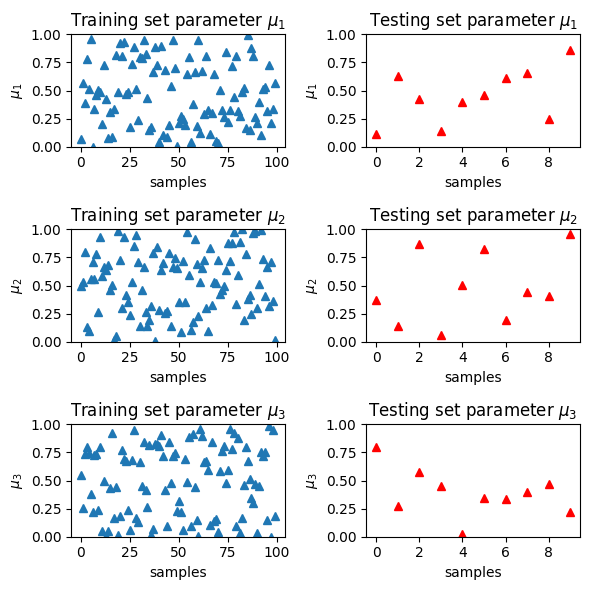

In [8]:
training = pod.sampling_parameters(num_training)
testing = pod.sampling_parameters(num_testing, test=True)
pod.plot_samples(figsize = (6, 6), filename=samples_fig)

In [9]:
pod.pod_execution(N_modes, tol)

STORING SNAPSHOTS...
+++ Compute and store snaphot 1 for mu = [0.06452592 0.49372974 0.55204157] +++
+++ Compute and store snaphot 2 for mu = [0.56926775 0.53554453 0.25111254] +++
+++ Compute and store snaphot 3 for mu = [0.39037041 0.79804742 0.73856874] +++
+++ Compute and store snaphot 4 for mu = [0.78125426 0.12713372 0.79765759] +++
+++ Compute and store snaphot 5 for mu = [0.50932276 0.09565585 0.74426958] +++
+++ Compute and store snaphot 6 for mu = [0.95837026 0.56216446 0.38134223] +++
+++ Compute and store snaphot 7 for mu = [0.00139832 0.71253849 0.22243216] +++
+++ Compute and store snaphot 8 for mu = [0.33187388 0.55772361 0.73059528] +++
+++ Compute and store snaphot 9 for mu = [0.46394559 0.7804225  0.73940381] +++
+++ Compute and store snaphot 10 for mu = [0.50068595 0.26202953 0.23987609] +++
+++ Compute and store snaphot 11 for mu = [0.48273681 0.92811586 0.80138003] +++
+++ Compute and store snaphot 12 for mu = [0.2046895  0.58213385 0.05243853] +++
+++ Compute and 

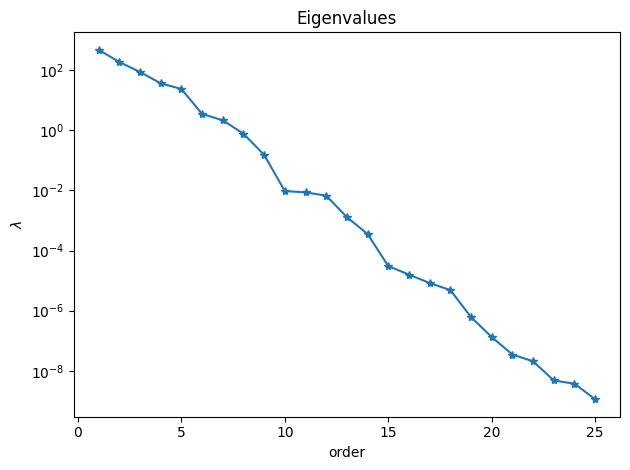

In [10]:
pod.plot_eigenvalues(filename=eig_fig)

In [11]:
pod.store_reduction(directory=dbdir, filename=model_name)

Start STORING REDUCTION......End STORING REDUCTION


In [12]:
mu_test = [.2, .6, .4]
mat, _ = pod.solve_rom(mu_test, pod.num_basis)
fom_m, _ = pod.fem_p.solve_fem(mu_test)
real_m, _ = pod.fem_p.exact_solution(mu_test)

print("ERRORE FOM-ESATTA")
e, f = pod.fem_p.compute_error(fom_m, real_m)
print("ERRORE ROM-FOM")
a, b = pod.fem_p.compute_error(mat, fom_m)
print("ERRORE ROM-ESATTA")
c, d = pod.fem_p.compute_error(mat, real_m)

ERRORE FOM-ESATTA
Errore Assoluto: 1.7453e+00
Errore Relativo: 1.2078e-01
ERRORE ROM-FOM
Errore Assoluto: 2.0874e-05
Errore Relativo: 1.5445e-06
ERRORE ROM-ESATTA
Errore Assoluto: 1.7453e+00
Errore Relativo: 1.2078e-01


In [13]:
error, _ = pod.error_analysis()


=============== POD basis number N = 1 ===============
Solve for test parameter i = 0, mu=[0.11647561 0.37002762 0.79906459]
Solve for test parameter i = 1, mu=[0.62699278 0.13940196 0.27331485]
Solve for test parameter i = 2, mu=[0.42136399 0.87135373 0.57604994]
Solve for test parameter i = 3, mu=[0.13821535 0.06318652 0.44723068]
Solve for test parameter i = 4, mu=[0.40180215 0.50514673 0.02567581]
Solve for test parameter i = 5, mu=[0.46210641 0.82328252 0.3459351 ]
Solve for test parameter i = 6, mu=[0.61080448 0.19760648 0.33201855]
Solve for test parameter i = 7, mu=[0.65436524 0.44052111 0.39696849]
Solve for test parameter i = 8, mu=[0.25017995 0.40889662 0.46990007]
Solve for test parameter i = 9, mu=[0.85978759 0.95797033 0.21795948]

=============== POD basis number N = 2 ===============
Solve for test parameter i = 0, mu=[0.11647561 0.37002762 0.79906459]
Solve for test parameter i = 1, mu=[0.62699278 0.13940196 0.27331485]
Solve for test parameter i = 2, mu=[0.42136399 0

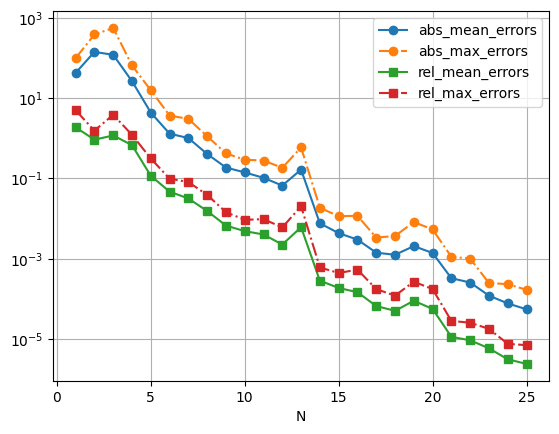

In [14]:
pod.plot_errors(error, filename=error_fig)

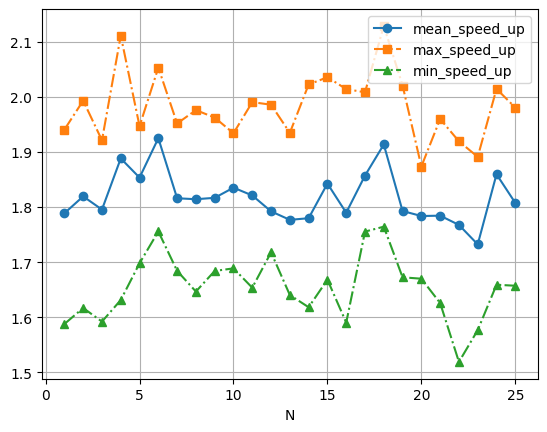

In [15]:
pod.plot_speed_up(error, filename=speed_up_fig)

In [16]:
pod.save_table_error(error)

In [17]:
pod.table_error(error)

Solution errors:
+-----+-----------------+----------------+--------------------------+-------------------------+------------+
|   N |   mean(error_u) |   max(error_u) |   mean(relative_error_u) |   max(relative_error_u) |   speed_up |
+=====+=================+================+==========================+=========================+============+
|   1 |    42.3021      |   98.4907      |              1.86713     |             4.96441     |    1.78862 |
+-----+-----------------+----------------+--------------------------+-------------------------+------------+
|   2 |   140.633       |  382.17        |              0.91916     |             1.54032     |    1.81926 |
+-----+-----------------+----------------+--------------------------+-------------------------+------------+
|   3 |   119.351       |  557           |              1.16838     |             3.83286     |    1.79531 |
+-----+-----------------+----------------+--------------------------+-------------------------+------------+
| 